In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest


In [ ]:
df = pd.read_csv('data/Sleep_health_and_lifestyle_dataset.csv')
df.head(25) # tarkistetaan aineiston ensimmäiset rivit

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [ ]:
df.shape # rivien ja sarakkeiden määrä

(374, 13)

In [ ]:
df.info() # tietotyypit ja puuttuvat arvot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
df.isnull().sum() # puuttuvien arvojen määrä sarakkeittain

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

## Data Cleaning

In [ ]:
df.duplicated().sum()  # tuplarivien määrä

np.int64(0)

In [ ]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")  # täytetään puuttuvat arvot
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})  # yhdistetään duplikaattiluokat

df[["BP_Systolic", "BP_Diastolic"]] = (
    df["Blood Pressure"]
    .str.split("/", expand=True)
    .astype(int)
)  # jaoin verenpaineen ylä ja alapaineeseen ja muutin arvot numeeriseen muotoon
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [ ]:
df["Sleep Disorder"].value_counts()  # kohdemuuttujan jakauma siivoamisen jälkeen  

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

## Eksploratiivinen data-analyysi (EDA)

In [ ]:
df.describe()  # yhteenvetotilastot numeerisille sarakkeille

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


## 2. Korrelaatioanalyysi

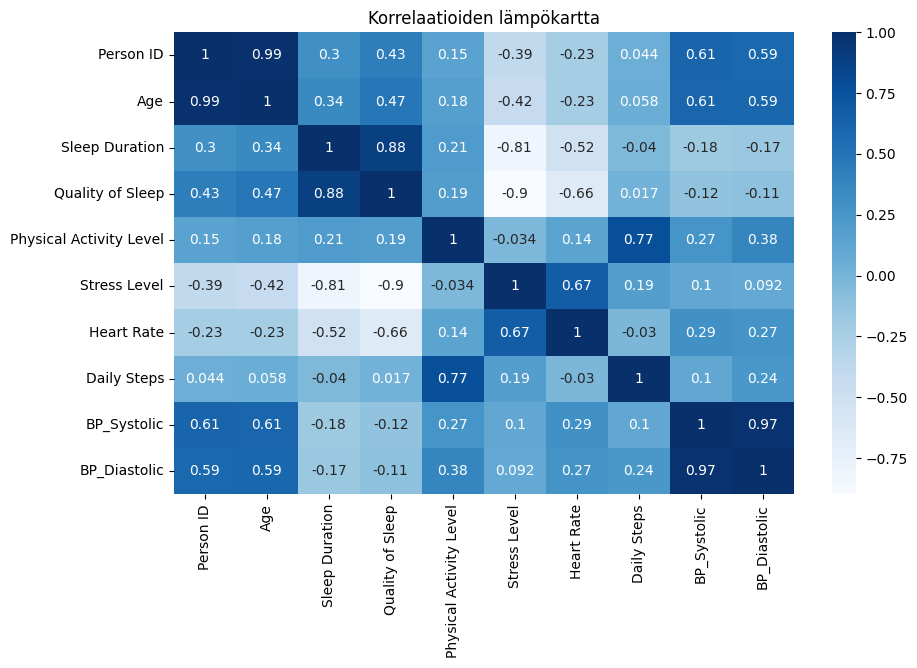

In [ ]:
numeric_data = df.select_dtypes(include=['int64', 'float64']) # valitaan vain numeeriset sarakkeet korrelaatiolaskentaa varten

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues") # luodaan korrelaatiolämpökartta numeerisista sarakkeista
plt.title("Korrelaatioiden lämpökartta") 
plt.show()

Vahvimmat positiiviset korrelaatiot: Sleep Duration - Quality of Sleep (0.88) ja Physical Activity Level - Daily Steps (0.77).
Vahvimmat negatiiviset korrelaatiot: Stress Level - Quality of Sleep (-0.90) ja Stress Level - Sleep Duration (-0.81).

1. Mitkä elämäntapatekijät ovat vahvimmin yhteydessä stressitasoon?

In [ ]:
stress_corr = numeric_data.corr()["Stress Level"].sort_values(ascending=False)
stress_corr

Stress Level               1.000000
Heart Rate                 0.670026
Daily Steps                0.186829
BP_Systolic                0.102818
BP_Diastolic               0.091811
Physical Activity Level   -0.034134
Person ID                 -0.394287
Age                       -0.422344
Sleep Duration            -0.811023
Quality of Sleep          -0.898752
Name: Stress Level, dtype: float64

Vahvimmat yhteydet stressitasoon:

Unen laatu (-0.90) ja unen kesto (-0.81) ovat vahvimmin yhteydessä stressiin - mitä enemmän stressiä, sitä huonompi 
ja lyhyempi uni.
Syke (0.67) on positiivisesti yhteydessä stressiin - stressaantuneilla on korkeampi syke.
Päivittäiset askeleet (0.19) ja fyysinen aktiivisuus (-0.03) eivät juuri liity stressiin tässä aineistossa.

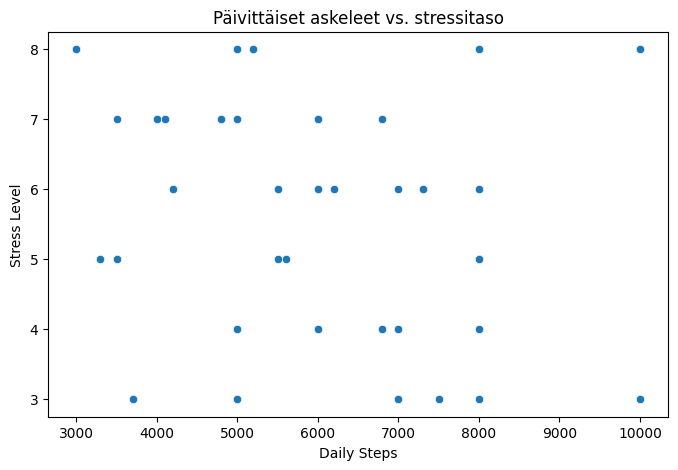

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Daily Steps", y="Stress Level")
plt.title("Päivittäiset askeleet vs. stressitaso")
plt.show()

2. Onko unihäiriöistä kärsivillä korkeampi stressitaso?

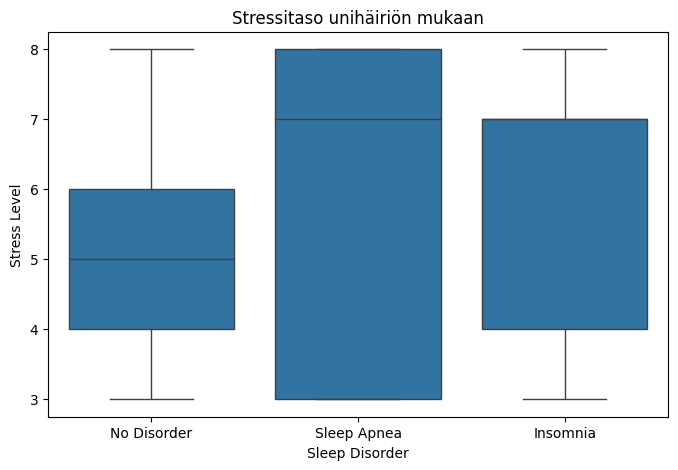

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Sleep Disorder", y="Stress Level")
plt.title("Stressitaso unihäiriön mukaan")
plt.show()

Unihäiriöt näyttävät liittyvän korkeampaan stressitasoon.

3. Näkyvätkö eri ammateissa erilaiset hyvinvointimallit?

In [ ]:
occupation_wellbeing = df.groupby("Occupation")[
    ["Stress Level", "Quality of Sleep", "Physical Activity Level"]
].mean().sort_values("Stress Level", ascending=False)
occupation_wellbeing

,Stress Level,Quality of Sleep,Physical Activity Level
Occupation,,,
Sales Representative,8.000000,4.000000,30.000000
Salesperson,7.000000,6.000000,45.000000
Scientist,7.000000,5.000000,41.000000
Doctor,6.732394,6.647887,55.352113
Software Engineer,6.000000,6.500000,48.000000
Nurse,5.547945,7.369863,78.589041
Lawyer,5.063830,7.893617,70.425532
Manager,5.000000,7.000000,55.000000
Accountant,4.594595,7.891892,58.108108


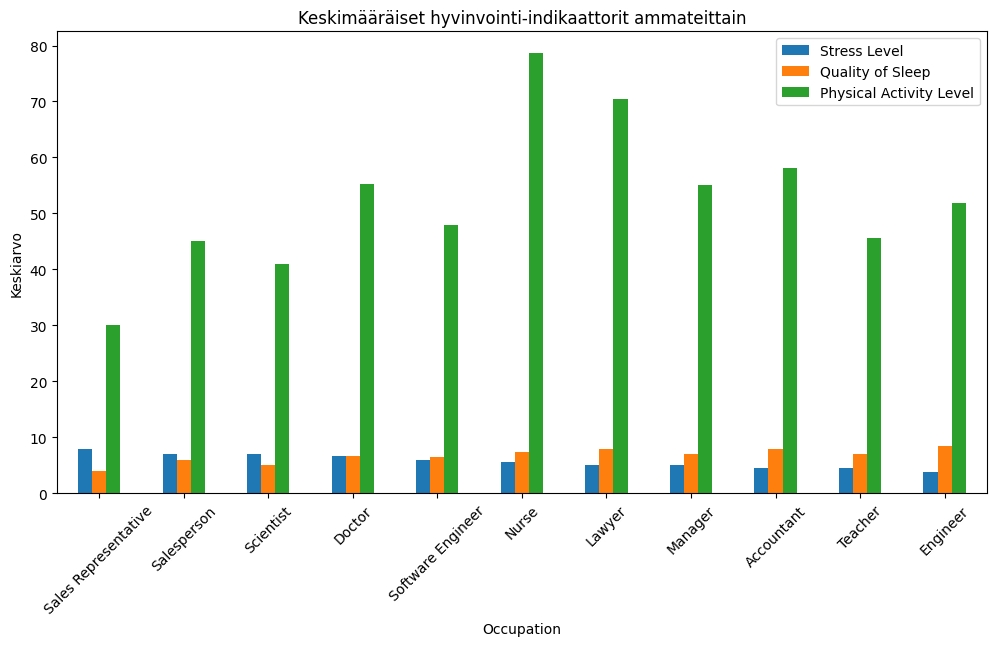

In [ ]:
occupation_wellbeing.plot(kind="bar", figsize=(12,6))
plt.title("Keskimääräiset hyvinvointi-indikaattorit ammateittain")
plt.ylabel("Keskiarvo")
plt.xticks(rotation=45)
plt.show()

Ammatit eroavat stressitasoltaan ja unen laadultaan.

4. Liittyykö korkeampi syke huonompaan unen laatuun?

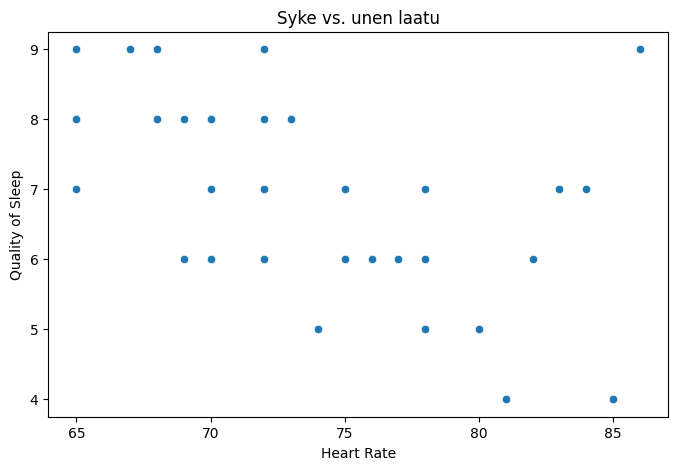

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Heart Rate", y="Quality of Sleep")
plt.title("Syke vs. unen laatu")
plt.show()

Korkeampi syke on yhteydessä alhaisempaan unen laatuun.

5. Eroavatko yli 35-vuotiaiden stressi ja aktiivisuusmallit?

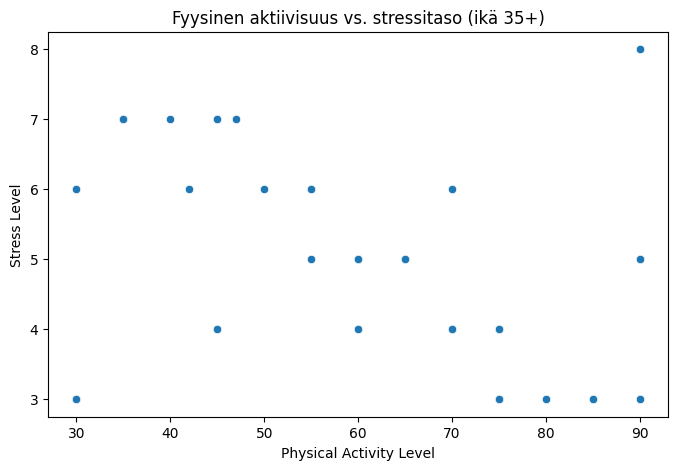

In [ ]:
df_35 = df[df["Age"] > 35]

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_35, x="Physical Activity Level", y="Stress Level")
plt.title("Fyysinen aktiivisuus vs. stressitaso (ikä 35+)")
plt.show()

Yli 35-vuotiailla alhaisempi aktiivisuus = korkeampi stressi.

6. Liittyvätkö epäterveelliset BMI-luokat sykkeen eroihin?

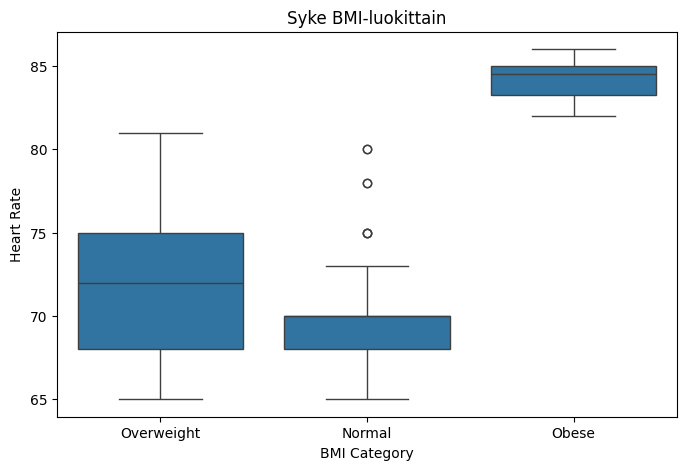

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="BMI Category", y="Heart Rate")
plt.title("Syke BMI-luokittain")
plt.show()

Obese-luokassa on korkeampi syke.

7. Miten unen kesto vaihtelee aineiston henkilöiden välillä?

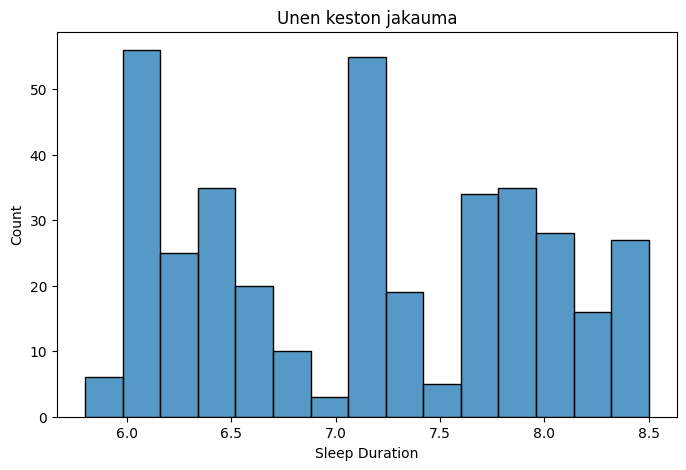

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Sleep Duration", bins=15)
plt.title("Unen keston jakauma")
plt.show()

Suurin osa nukkuu 6-8 tuntia yössä.

8. Onko sykkeen jakaumassa eroja miesten ja naisten välillä?

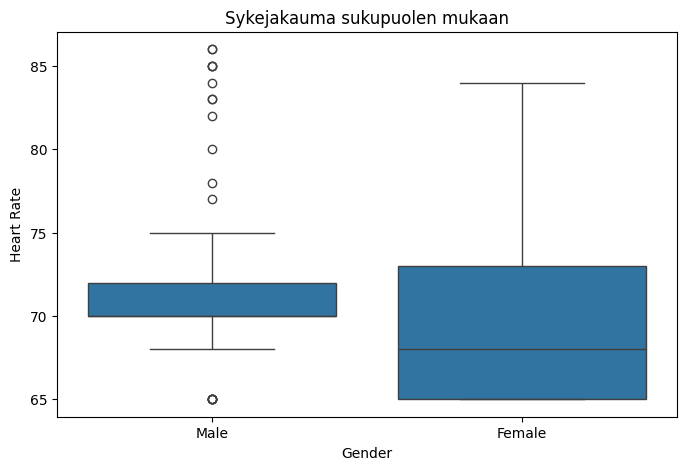

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Gender", y="Heart Rate")
plt.title("Sykejakauma sukupuolen mukaan")
plt.show()

In [ ]:
df[df["Gender"] == "Female"]["Heart Rate"].describe()

count    185.000000
mean      69.259459
std        4.431573
min       65.000000
25%       65.000000
50%       68.000000
75%       73.000000
max       84.000000
Name: Heart Rate, dtype: float64

Naisten sykkeessä on laajempi vaihteluväli. Keskiarvo on noin 69 bpm.

# EDAn johtopäätös

Stressitaso on keskeisin indikaattori: se on vahvasti negatiivisesti yhteydessä sekä unen laatuun että kestoon, ja myös päivittäisiin askeliin ja fyysiseen aktiivisuuteen. Diagnosoiduista unihäiriöistä kärsivillä on korkeampi stressitaso.
Suurin osa osallistujista nukkuu 6-8 tuntia yössä. Eri ammateissa hyvinvointimallit eroavat selvästi, ja yli 35-vuotiailla alhaisempi aktiivisuus on yhteydessä korkeampaan stressiin. Syke eroaa BMI-luokkien välillä ja hieman myös sukupuolten välillä.
Uni, stressi, aktiivisuus ja perusterveydentilan indikaattorit ovat selvästi yhteydessä toisiinsa.

# Koneoppiminen - Poikkeavuuksien tunnistus Isolation Forestilla

Tavoitteena on löytää henkilöt, joiden hyvinvointiprofiili näyttää epätavalliselta. 
Isolation Forest ei ennusta diagnoosia, vaan tunnistaa havaintoja, jotka eroavat normaaleista malleista. 'Sleep Disorder' saraketta ei käytetä syötteenä, vaan vain riippumattomana tarkistuksena lopussa.

1. Aineiston valmistelu koneoppimista varten

In [ ]:
df_ml = df.copy()  # luodaan kopio alkuperäisestä datasta ML-analyysiä varten
df_ml.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


2. Piirteiden valinta

In [ ]:
sleep_disorder_check = df_ml["Sleep Disorder"]  # tallennetaan kohdemuuttuja erikseen
df_ml = df_ml.drop(columns=["Person ID", "Blood Pressure", "Sleep Disorder"])  # poistetaan ei-numeeriset ja kohdemuuttuja
df_ml.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90


Sleep Disorder tallennettiin erikseen myöhempää tarkistusta varten.

3. Kategoristen piirteiden koodaus

In [ ]:
df_ml["Gender"] = df_ml["Gender"].map({"Female": 0, "Male": 1})

# BMI Category
bmi_order = {"Normal": 0, "Overweight": 1, "Obese": 2}
df_ml["BMI Category"] = df_ml["BMI Category"].map(bmi_order)

# Occupation
df_ml = pd.get_dummies(df_ml, columns=["Occupation"], drop_first=True)  # luodaan dummy-muuttujat ammatille koska  
                                                    # ML-mallit vaativat numeerista dataa, 
                                                    # mutta ammatti ei voi olla korkeampi tai matalampi kuin toinen
df_ml.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,BP_Systolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,27,6.1,6,42,6,1,77,4200,126,...,False,False,False,False,False,False,False,False,True,False
1,1,28,6.2,6,60,8,0,75,10000,125,...,True,False,False,False,False,False,False,False,False,False
2,1,28,6.2,6,60,8,0,75,10000,125,...,True,False,False,False,False,False,False,False,False,False
3,1,28,5.9,4,30,8,2,85,3000,140,...,False,False,False,False,False,True,False,False,False,False
4,1,28,5.9,4,30,8,2,85,3000,140,...,False,False,False,False,False,True,False,False,False,False


4. Isolation Forest malli

In [ ]:
# Testataan eri contamination-arvoja sopivan arvon valitsemiseksi
for cont in [0.05, 0.10, 0.15]:
    m = IsolationForest(contamination=cont, random_state=42)  # luodaan malli eri contamination-arvoilla
    preds = m.fit_predict(df_ml) # ennustetaan poikkeavuudet datasta
    print(f"contamination={cont}: anomalies={sum(preds==-1)}") 


contamination=0.05: anomalies=19
contamination=0.1: anomalies=38
contamination=0.15: anomalies=56


Testatut arvot 0.05 ja 0.15 tuottivat joko liian vähän tai liian paljon poikkeavuuksia suhteessa aineiston kokoon, sen takia otan 0.1.

In [ ]:
model = IsolationForest(contamination=0.1, random_state=42) # valittu arvo 0.1 (noin 10% aineistosta ja mallien toistettavuus varmistus) 
model.fit(df_ml)

,n_estimators,100
,max_samples,'auto'
,contamination,0.1
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [ ]:
df["Anomaly"] = model.predict(df_ml)  # lisätään ennusteet alkuperäiseen datakehykseen
df["Anomaly"].value_counts()  # normaalien ja poikkeavien havaintojen määrä

Anomaly
 1    336
-1     38
Name: count, dtype: int64

1 = normaali, -1 =poikkeavuus

5. Normaalien havaintojen ja poikkeavuuksien vertailu

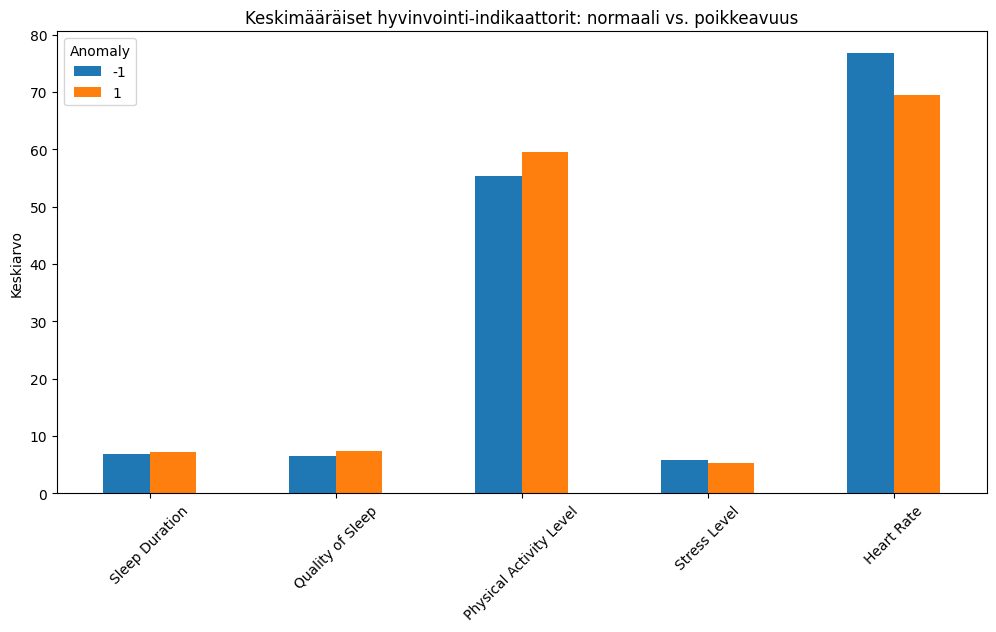

In [ ]:
cols_compare = ["Sleep Duration", "Quality of Sleep", "Physical Activity Level",
                "Stress Level", "Heart Rate"]

df.groupby("Anomaly")[cols_compare].mean().T.plot(kind="bar", figsize=(12,6))
plt.title("Keskimääräiset hyvinvointi-indikaattorit: normaali vs. poikkeavuus")
plt.ylabel("Keskiarvo")
plt.xticks(rotation=45)
plt.show()

Poikkeavuuksilla on korkeampi syke ja stressitaso sekä alhaisempi aktiivisuus ja huonommat uni-indikaattorit.

Poikkeavuudet hyvinvointidatassa

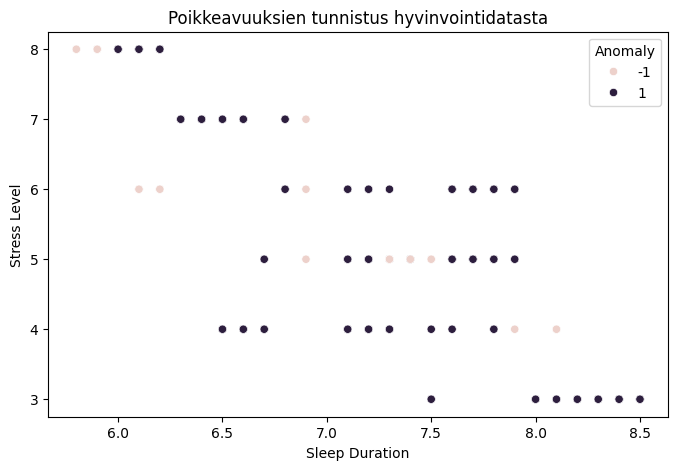

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sleep Duration", y="Stress Level", hue="Anomaly")
plt.title("Poikkeavuuksien tunnistus hyvinvointidatasta")
plt.show()

Malli löysi kaksi poikkeavaa ryhmää:
- vähän nukkuvat, paljon stressiä > hyvinvointiriski
- paljon nukkuvat, vähän stressiä > epätavallisen terveet

6. Poikkeavuuksien vertaaminen unihäiriöihin

In [ ]:
pd.crosstab(df["Anomaly"], sleep_disorder_check, normalize="index").round(3) * 100 # tarkastellaan poikkeavuuksien 
                                                                  # ja unihäiriöiden välistä yhteyttä prosentteina

Sleep Disorder,Insomnia,No Disorder,Sleep Apnea
Anomaly,,,
-1,21.1,42.1,36.8
1,20.5,60.4,19.0


Poikkeavuuksien ryhmässä (-1) vain 42% on terveitä.
Normaalien ryhmässä (1) terveitä on 60%.
Eli Poikkeavuuksissa on suhteessa enemmän unihäiriöisiä.

In [ ]:
from sklearn.metrics import classification_report

# tarkistetaan miten hyvin malli löysi unihäiriöiset henkilöt
y_true = (sleep_disorder_check != "No Disorder").astype(int) # todelliset arvot aineistosta
y_pred = (df["Anomaly"] == -1).astype(int) # y_pred = mallin ennusteet

print(classification_report(y_true, y_pred, target_names=["Ei häiriötä", "Unihäiriö"]))

              precision    recall  f1-score   support

 Ei häiriötä       0.60      0.93      0.73       219
   Unihäiriö       0.58      0.14      0.23       155

    accuracy                           0.60       374
   macro avg       0.59      0.53      0.48       374
weighted avg       0.59      0.60      0.52       374



Malli tunnisti oikein 60% kaikista tapauksista.
Terveet henkilöt: malli löysi 93% oikein - tämä on hyvä tulos.
Unihäiriöiset: malli löysi vain 14% - tämä johtuu siitä, että malli ei ole diagnoosityökalu. 

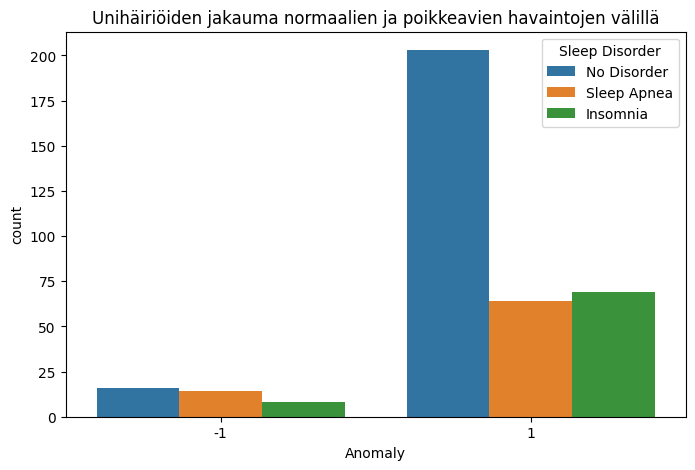

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Anomaly", hue=sleep_disorder_check)
plt.title("Unihäiriöiden jakauma normaalien ja poikkeavien havaintojen välillä")
plt.show()

Poikkeavuuksien ryhmässä (-1) unihäiriöisiä on suhteessa paljon enemmän kuin normaalien ryhmässä (1).
Normaaleista 60% on terveitä.Poikkeavuuksista vain 42% on terveitä. Malli löysi oikeat ihmiset ilman diagnoosia.

Isolation Forest löysi ryhmän henkilöitä, joilla on epätavallinen hyvinvointiprofiili. Heillä on korkeampi stressi, alhaisempi aktiivisuus ja huonompi uni. Diagnosoiduista unihäiriöistä kärsivien osuus on suurempi heidän joukossaan, mikä tarkoittaa, että malli tunnisti merkityksellisiä malleja eikä satunnaista hälyä.
Malli ei ennusta diagnoosia, mutta voi nostaa esiin yksilöitä, jotka voivat tarvita tarkempaa huomiota ennaltaehkäisevässä hyvinvointianalyysissä.

## Mallin arviointi 
Sleep Disorder muuttujaa käytettiin mallin arviointiin

In [ ]:
from sklearn.metrics import confusion_matrix

true_labels = sleep_disorder_check.replace({
    "No Disorder": 0, # 0 = ei unihäiriötä
    "Insomnia": 1, # 1 = unihäiriö
    "Sleep Apnea": 1 # 1 = unihäiriö
}).astype(int)

pred_labels = df["Anomaly"].replace({
    1: 0, # 1 = normaali havainto
    -1: 1 # -1 = poikkeavuus
}).astype(int)

cm = confusion_matrix(true_labels, pred_labels)
cm

C:\Users\roman\AppData\Local\Temp\ipykernel_22320\1838129970.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  true_labels = sleep_disorder_check.replace({


array([[203,  16],
       [133,  22]])

203 = terveet tunnistettiin oikein 
16  = terveet tunnistettiin väärin
133 = unihäiriöiset jäi löytämättä
22  = unihäiriöiset tunnistettiin oikein

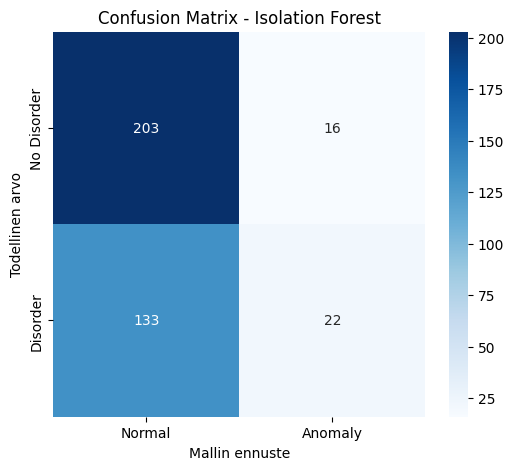

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["No Disorder", "Disorder"]
)

plt.xlabel("Mallin ennuste")
plt.ylabel("Todellinen arvo")

plt.title("Confusion Matrix - Isolation Forest")

plt.show()

Confusion matrix osoittaa:
- 22 unihäiriöistä löytyi oikein
- 203 tervettä tunnistettiin oikein
- 133 unihäiriöistä jäi löytämättä203 = terveet tunnistettiin oikein 
- 16 = terveet tunnistettiin väärin


## Mallin arviointi

Malli ei oppinut diagnooseista - Sleep Disorder sarake poistettiin ennen mallin rakentamista.
Arvioinnissa vertasin mallin löytämiä poikkeavuuksia oikeisiin diagnooseihin jälkikäteen.
Tulos: poikkeavuuksien ryhmässä oli enemmän unihäiriöisiä kuin normaalien ryhmässä, eli malli löysi oikeat ihmiset.

# Mallien vertailu - Isolation Forest ja Local Outlier Factor

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1) # tarkistus naapurilla perustuvalla menetelmällä, valittu arvo 0.1 (noin 10% aineistosta)
df["LOF_Anomaly"] = lof.fit_predict(df_ml) # ennustetaan poikkeavuudet datasta ja tallennetaan uusi sarake alkuperäiseen dataan
df["LOF_Anomaly"].value_counts()

LOF_Anomaly
 1    336
-1     38
Name: count, dtype: int64

In [ ]:
comparison = pd.crosstab(
  df["Anomaly"], 
  df["LOF_Anomaly"]
)
comparison

LOF_Anomaly,-1,1
Anomaly,,
-1,26,12
1,12,324


Molemmat mallit löysivät samat 26 poikkeavuutta.
12 tapausta erosi mallien välillä.
324 henkilöä tunnistettiin normaaleiksi molemmissa malleissa.

Mallit ovat pitkälti samaa mieltä — tulos on luotettava.

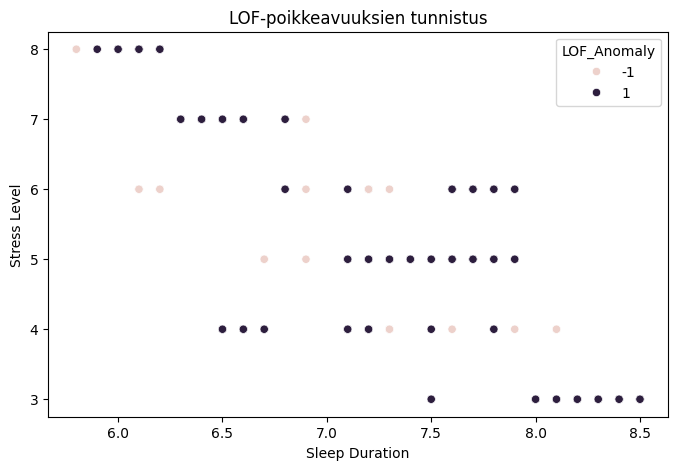

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sleep Duration", y="Stress Level", hue="LOF_Anomaly")
plt.title("LOF-poikkeavuuksien tunnistus")
plt.show()

## Mallien vertailu

Isolation Forest ja Local Outlier Factor Molemmat mallit tunnistivat samankaltaisia​ henkilöitä, joilla on enemmän stressiä, huonompi uni ja vähemmän liikuntaa.

26 poikkeavuutta löytyi molemmilla malleilla.
12 tapausta erosi mallien välillä.

Isolation Forest - vakaampi tulos, koska näkee koko kuvan. ​
LOF - herkempi paikallisille eroille, koska vertaa jokaista lähimpiin.​

Valinta: Isolation Forest - sopii paremmin pienelle aineistolle (374 henkilöä).​

In [ ]:
shared_anomalies = df[
    (df["Anomaly"] == -1) &
    (df["LOF_Anomaly"] == -1)
]

shared_anomalies[[
    "Age",
    "Gender",
    "Occupation",
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Heart Rate",
    "Sleep Disorder"
]]

,Age,Gender,Occupation,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level,Heart Rate,Sleep Disorder
0,27,Male,Software Engineer,6.1,6,6,42,77,No Disorder
1,28,Male,Doctor,6.2,6,8,60,75,No Disorder
2,28,Male,Doctor,6.2,6,8,60,75,No Disorder
3,28,Male,Sales Representative,5.9,4,8,30,85,Sleep Apnea
4,28,Male,Sales Representative,5.9,4,8,30,85,Sleep Apnea
5,28,Male,Software Engineer,5.9,4,8,30,85,Insomnia
30,30,Female,Nurse,6.4,5,7,35,78,Sleep Apnea
31,30,Female,Nurse,6.4,5,7,35,78,Insomnia
32,31,Female,Nurse,7.9,8,4,75,69,No Disorder
68,33,Female,Scientist,6.2,6,6,50,76,No Disorder


In [ ]:
shared_anomalies[[ # tarkastellaan yhteisiä poikkeavuuksia ja niiden keskiarvoja hyvinvointi-indikaattoreista
    "Stress Level",
    "Quality of Sleep",
    "Physical Activity Level",
    "Heart Rate"
]].mean()

Stress Level                6.038462
Quality of Sleep            6.269231
Physical Activity Level    52.115385
Heart Rate                 75.115385
dtype: float64

In [ ]:
normal_people = df[ # tarkastellaan henkilöitä, jotka eivät olleet poikkeavuuksia kummassakaan mallissa
    (df["Anomaly"] == 1) &
    (df["LOF_Anomaly"] == 1)
]

normal_people[[
    "Stress Level",
    "Quality of Sleep",
    "Physical Activity Level",
    "Heart Rate"
]].mean()

Stress Level                5.358025
Quality of Sleep            7.388889
Physical Activity Level    59.660494
Heart Rate                 69.475309
dtype: float64

In [ ]:
comparison_table = pd.DataFrame({ # vertailutaulukko yhteisistä poikkeavuuksista ja normaaleista henkilöistä hyvinvointi-indikaattoreiden keskiarvoista
    "Normal": normal_people[[
        "Stress Level",
        "Quality of Sleep",
        "Physical Activity Level",
        "Heart Rate",
        "Sleep Duration"
    ]].mean(),

    "Anomalies": shared_anomalies[[ 
        "Stress Level",
        "Quality of Sleep",
        "Physical Activity Level",
        "Heart Rate",
        "Sleep Duration"
    ]].mean()
})

comparison_table.round(2)

,Normal,Anomalies
Stress Level,5.36,6.04
Quality of Sleep,7.39,6.27
Physical Activity Level,59.66,52.12
Heart Rate,69.48,75.12
Sleep Duration,7.16,6.77


Poikkeavuuksilla on selkeä profiili verrattuna normaaleihin:korkeampi stressi, korkeampi syke ja huonompi uni.
Malli tunnisti hyvinvoinnin kannalta riskialttiita henkilöitä.

In [ ]:
anomaly_jobs = shared_anomalies["Occupation"].value_counts() # tarkastellaan poikkeavuuksiksi tunnistettujen henkilöiden ammatteja

anomaly_jobs

Occupation
Nurse                   6
Doctor                  4
Scientist               4
Software Engineer       2
Sales Representative    2
Teacher                 2
Engineer                2
Accountant              2
Lawyer                  1
Manager                 1
Name: count, dtype: int64

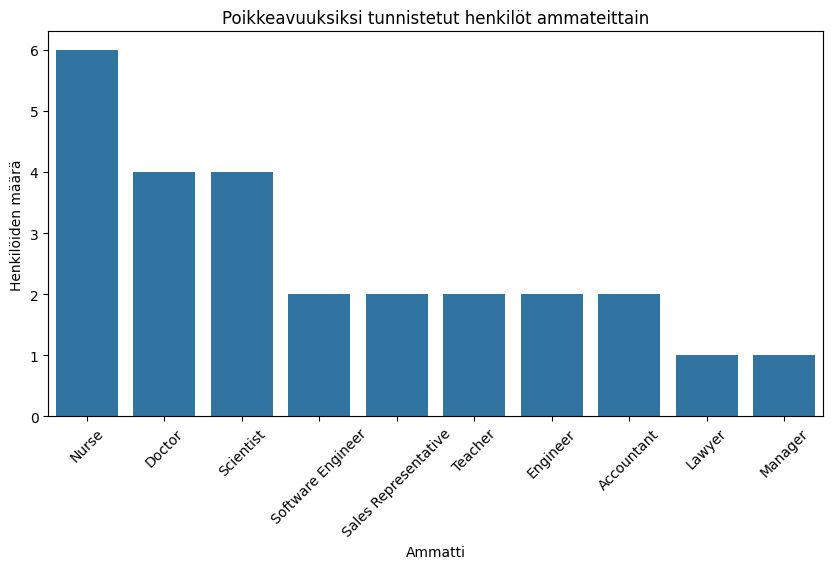

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot( # visualisoidaan poikkeavuuksiksi tunnistettujen henkilöiden ammatit
    data=shared_anomalies,
    x="Occupation",
    order=shared_anomalies["Occupation"].value_counts().index
)

plt.title("Poikkeavuuksiksi tunnistetut henkilöt ammateittain")
plt.xlabel("Ammatti")
plt.ylabel("Henkilöiden määrä")

plt.xticks(rotation=45) # parantaa luettavuutta, jos ammatit ovat pitkiä tai monimutkaisia

plt.show()

## Ammattien tarkastelu

Eniten poikkeavuuksia löytyi: Nurse (6), Doctor (4), Scientist (4).

Tämä voi viitata siihen, että näissä ammateissa stressi ja unen laatu ovat heikompia.
Työhyvinvoinnin seuranta voisi olla hyödyllistä erityisesti näissä ammattiryhmissä.

## Hypoteesien tarkistus

1. Vähemmän askelia = korkeampi stressi. 
    Korrelaatio 0.19 - yhteys liian heikko. **Ei tuettu.**
2. Yli 35-vuotiailla alhaisempi aktiivisuus > korkeampi stressi.
    Hajontakuvio ei näytä selkeää trendiä. **Ei tuettu.**
3. BMI-luokka vaikuttaa sykkeeseen.
    Obese-ryhmän syke (84) on selvästi korkeampi kuin Normal-ryhmän (69). **Tuettu**
4. Joillakin ammateilla korkeampi stressi ja huonompi uni.
    Sales Representative - ammatin stressitaso (8) on lähes kaksinkertainen Engineer-ammattiin (4) verrattuna **Tuettu**
5. Miesten ja naisten syke eroaa toisistaan.
    Miesten keskisyke (~71) on hieman korkeampi kuin naisten (~69), mutta naisten sykkeen vaihteluväli on huomattavasti suurempi (65–84). **Osittain tuettu**

## Lopullinen johtopäätös
Stressi vaikuttaa eniten uneen ja hyvinvointiin.
Malli löysi 38 henkilöä, joilla on riskiprofiili enemmän stressiä, huonompi uni ja korkeampi syke.
Poikkeavuuksien joukossa oli enemmän unihäiriöisiä.

Yksinkertainen elämäntapadata riittää riskien tunnistamiseen.

## Rajoitukset
Aineisto on pieni (374 henkilöä).
Stressi ja uni perustuvat itsearviointiin, ei objektiivista mittausta.
Malli ei diagnosoi, se löytää epätavallisia profiileja.


## Jatkotoimenpiteet
Tunnistetut riskiryhmät voisivat hyötyä hyvinvointivalmennuksesta.
Isommalla aineistolla tulokset olisivat luotettavampia.